# An example `DatasetCohort`, built on the mock release

`serl-dataset` wraps the SERL Observatory into the `building_energy_analysis` (BEA) framework.
This notebook builds a **complete, working cohort from scratch** against the `serl-mock`
stand-in release, so the whole path can be exercised outside the secure environment:

release CSVs → **DuckDB input store** → cohort roster → one household → BEA `Data`.

What it demonstrates, in order:

| Step | What it shows |
|---|---|
| 1 | The **input config** — where a release's files are, and how the config layer resolves them |
| 2 | A **`PUPRNInfo` spec** — declaring the household attributes once, for both tables that need them |
| 3 | The **cohort class** — `SERLBaseMixin` + `DatasetCohort`, and what each contributes |
| 4–6 | Constructing it, opting into the store, and **building** the store from the CSVs |
| 7–8 | The **roster** (datasets table), then one household as a `SERLHome` |
| 9 | **Cohort-wide** queries — the thing only the store can answer |
| 10 | The **parquet cache**, and swapping backends with no code change |
| 11–12 | Variations, and what changes for the real release |

**Prerequisites**

* The workspace venv, installed from the workspace root with `uv sync --all-packages`
  (`serl-dataset`, `serl-mock` and their dependencies all present).
* The mock release generated into `serl-mock/data/mock/` — `python scripts/generate_mock_data.py`
  if it is not there yet. It is gitignored, so a fresh clone has to generate it.

Everything this notebook writes lands in `notebooks/example_cohort_workspace/`, which is
gitignored and safe to delete (last cell).

## 0. A working directory

`project_configuration` resolves `Configuration_files/`, `Logs/` and `Results/` **relative to the
working directory the process starts in** — not relative to the package or the notebook. So the
first thing to settle is where "here" is; everything after this depends on it.

`make_config_dirs()` creates `Configuration_files/Config_settings/` and its config-type registry.
It is a first-run-in-a-fresh-directory step, and a no-op afterwards.

In [1]:
import os
from pathlib import Path

from serl_mock.paths import MOCK_DIR, PROJECT_ROOT
from project_configuration.config.config_settings import make_config_dirs

WORK_DIR = PROJECT_ROOT / 'notebooks' / 'example_cohort_workspace'
WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

# Collapse both config layers onto the scratch dir. Without this the cohort's machine-scoped
# sections (input_dirs, column maps, units) land in this machine's real config home -- e.g.
# %LOCALAPPDATA%\project-configuration -- and outlive the demo. Same trick a cluster job uses.
os.environ['PROJECT_CONFIGURATION_HOME'] = str(WORK_DIR / 'Configuration_files')
make_config_dirs()

print('working directory:', Path.cwd())
print('mock release     :', MOCK_DIR)

working directory: C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace
mock release     : C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\data\mock


In [2]:
# The stand-in Edition 08 release this cohort will be built from.
for path in sorted(MOCK_DIR.iterdir()):
    print(f"{'DIR ' if path.is_dir() else '    '}{path.name}")

    bst_dates_to_2030.csv
DIR mock_internal
    serl_2023_follow_up_survey_data_edition08.csv
DIR serl_aggregated_data
DIR serl_climate_data_edition08
    serl_covid19_survey_data_dictionary_edition08.csv
    serl_covid19_survey_data_edition08.csv
    serl_energy_use_in_GB_domestic_buildings_2021_aggregated_statistics_edition07.csv
    serl_epc_data_edition08.csv
    serl_participant_summary_edition08.csv
DIR serl_smart_meter_daily_edition08
DIR serl_smart_meter_hh_edition08
    serl_smart_meter_rt_summary_edition08.csv
    serl_survey_data_dictionary_edition08.csv
    serl_survey_data_edition08.csv
    serl_tariff_data_edition08.csv


## 1. The input config: where the release lives

Two `Settings` layers matter, and the difference between them is the core idea:

* **`serl_input_settings`** — where the *raw release* is, and where prep output goes.
* **`serl_base_settings`** — the *cohort* settings: parameter-name → column-name maps, units, and
  an `input_dirs` that is literally `serl_input_settings`' `output_dirs`.

That is, **the prep step's output directories are the cohort's input directories.** Raw CSVs are
read once, by the prep step; everything downstream reads what prep produced.

`InputConfig(name='...')` resolves to `Configuration_files/Datasets/<name>_config.toml`. Every
path in it ships as `""` and is filled in per environment — which is why `Configuration_files/`
is gitignored and never synced between environments.

Writing it through `update_with_settings(..., save=True)` rather than hand-editing the TOML
matters: the config file is also read back by consumers that construct their config *without*
the settings object (BEA's per-household `Dataset` does exactly that), so the file has to end up
holding the full merged configuration, not just the keys you happened to type.

In [3]:
from serl_dataset.config.input_config import InputConfig
from serl_dataset.config.serl_input_data_settings import serl_input_settings

INPUT_CONFIG_NAME = 'MockObservatory_input'
CACHE_DIR = WORK_DIR / 'energy_climate_data'   # where the parquet cache will go (step 10)

input_config = InputConfig(name=INPUT_CONFIG_NAME, settings=serl_input_settings)
input_config.update_with_settings(
    dict(
        input_dirs=dict(
            # Directories of monthly files...
            energy_data_dir=str(MOCK_DIR / 'serl_smart_meter_hh_edition08'),
            climate_data_dir=str(MOCK_DIR / 'serl_climate_data_edition08'),
            # ...and single files. (The `*_dir` names are historical: most point at a file.)
            epc_data_dir=str(MOCK_DIR / 'serl_epc_data_edition08.csv'),
            participants_data_dir=str(MOCK_DIR / 'serl_participant_summary_edition08.csv'),
            survey_data_dir=str(MOCK_DIR / 'serl_survey_data_edition08.csv'),
            follow_up_survey_data_dir=str(MOCK_DIR / 'serl_2023_follow_up_survey_data_edition08.csv'),
            smart_meter_summary_dir=str(MOCK_DIR / 'serl_smart_meter_rt_summary_edition08.csv'),
        ),
        output_dirs=dict(energy_climate_data_dir=str(CACHE_DIR)),
    ),
    overwrite=True, save=True)

print(input_config.filepath, end='\n\n')
print(Path(input_config.filepath).read_text())

C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\Configuration_files\Datasets\MockObservatory_input_config.toml

[input_dirs]
energy_data_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock\\serl_smart_meter_hh_edition08"
climate_data_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock\\serl_climate_data_edition08"
epc_data_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock\\serl_epc_data_edition08.csv"
participants_data_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock\\serl_participant_summary_edition08.csv"
survey_data_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock\\serl_survey_data_edition08.csv"
follow_up_survey_data_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock\\serl_2023_follow_up_surv

## 2. Declare the household attributes

A cohort needs the same per-household facts in two unrelated places:

* the **results-side** SQLAlchemy `datasets` table — BEA's roster of `dataset_id`/`status`, which
  `_puprn_filters()` queries, and
* the **input-side** DuckDB `puprn_info` table — the flat row joined to the meter readings.

Declaring them twice is how they drift, so a cohort declares them **once**, as a tuple of
`InfoColumn`, and `PUPRNInfo` generates both. `InfoColumn(source, column, type, name=...)`:

* `source` — one of the store's faithfully-loaded release tables, and it must be **one row per
  household**: `participants`, `epc`, `survey`, `follow_up_survey`. (`rt_summary` is rejected —
  it ships several rows per household and cannot flatten without an aggregation you should
  choose yourself.)
* `column` — the release's own column name; `name` renames it for our tables.

Which attributes a cohort wants is an analysis decision, so it lives in code, next to the
cohort — not in environment-local TOML.

In [4]:
from sqlalchemy import Integer

from serl_dataset.datasets.puprn_info_spec import DefaultPUPRNInfo, InfoColumn


class MockObservatoryInfo(DefaultPUPRNInfo):
    """The default attributes, plus two the mock survey happens to carry."""

    columns = DefaultPUPRNInfo.columns + (
        InfoColumn('survey', 'B1013', Integer, name='cooling'),
        InfoColumn('survey', 'C2_tot_adult', Integer, name='n_adults'),
    )


print('inherited from DefaultPUPRNInfo:')
for column in DefaultPUPRNInfo.columns:
    print(f'  {column.source:<14} {column.column:<22} -> {column.target}')

print('\ndeclared here:')
for column in MockObservatoryInfo.columns[len(DefaultPUPRNInfo.columns):]:
    print(f'  {column.source:<14} {column.column:<22} -> {column.target}')

print('\ntargets():', MockObservatoryInfo.targets())

inherited from DefaultPUPRNInfo:
  participants   Region                 -> region
  participants   IMD_quintile           -> imd_quintile
  epc            totalFloorArea         -> totalFloorArea
  epc            propertyType           -> property_type
  epc            builtForm              -> built_form
  epc            constructionAgeBand    -> construction_age_band
  epc            tenure                 -> tenure

declared here:
  survey         B1013                  -> cooling
  survey         C2_tot_adult           -> n_adults

targets(): ('region', 'imd_quintile', 'totalFloorArea', 'property_type', 'built_form', 'construction_age_band', 'tenure', 'cooling', 'n_adults')


> **`targets()`, not `dataset_table().__table__.columns`.** BEA fixes the table name to
> `datasets` and there is one declarative base per process, so every spec's generated class
> shares a single `Table`; load two SERL cohorts in one process and both report the union of
> their columns. `targets()` is per-spec and unaffected. The DuckDB `puprn_info` table *is*
> genuinely per-cohort — it is rebuilt from `columns` each time.

## 3. The cohort class

Three things make a SERL cohort:

```python
class MockObservatory(SERLBaseMixin, DatasetCohort):
```

* **`SERLBaseMixin` comes first.** It has to resolve ahead of `DatasetCohort` in the MRO: it
  builds the `InputConfig`, the cached release reader and the input backend, and supplies the
  `dataset_table` from `puprn_info_spec` before `DatasetCohort.__init__` wants one.
* **`settings=serl_base_settings`** carries the energy/climate parameter maps and units — which
  release column is `elec`, which is `temp_ext`, and what units they are in.
* **`input_config_name`** points at the input config from step 1. It defaults to `'SERL_input'`;
  override it when a cohort's release lives somewhere of its own (`ghg-dataset` has one per
  strand).

Optionally, `_puprn_filters()` restricts the cohort to households matching declared attributes
— see step 11.

In [5]:
from building_energy_analysis import DatasetCohort

from serl_dataset.config.serl_base_settings import serl_base_settings
from serl_dataset.datasets.serl_base_mixin import SERLBaseMixin


class MockObservatory(SERLBaseMixin, DatasetCohort):
    """Every household in the serl-mock stand-in release, with no analysis-specific filter."""

    puprn_info_spec = MockObservatoryInfo
    input_config_name = INPUT_CONFIG_NAME

    def __init__(self, **kwargs):
        super().__init__(settings=serl_base_settings, **kwargs)


print([klass.__name__ for klass in MockObservatory.__mro__[:5]])

['MockObservatory', 'SERLBaseMixin', 'DatasetCohort', 'BaseDataset', 'ABC']


## 4. Construct it

Constructing the cohort merges `serl_base_settings` with BEA's dataset defaults — the parameter
maps, units, `input_dirs`, results location, logging — in memory. Nothing is read from disk yet:
the input backend is resolved lazily, on first use.

Construction does not write the file; `save()` does, to
`Configuration_files/Datasets/MockObservatory_config.toml`. Because cell 0 collapsed both config
layers onto the scratch dir, that is one merged file. (Outside a collapsed setup, `save()`
demerges instead: data-source sections go to this machine's config home, analysis sections to
the project's `Configuration_files/` — see project-configuration ADR 0001.)

The parameter maps and units are not in it: they are *injected* sections, which the code supplies
on every read, so a copy in a file could only go stale. The file holds what is per-environment.

Note `[input_dirs] energy_climate_data_dir` in the file below. That is `serl_input_settings`'
**output** dir arriving as the cohort's **input** dir — the mechanism described in step 1.

In [6]:
cohort = MockObservatory()
cohort.dataset_config.save()       # construction merges in memory; this writes the file

print(cohort, '->', cohort.dataset_config.filepath, end='\n\n')
print(Path(cohort.dataset_config.filepath).read_text())

MockObservatory() -> C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\Configuration_files\Datasets\MockObservatory_config.toml

[input_dirs]
energy_climate_data_dir = "energy_climate_data"
input_base_dir = "C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\notebooks\\example_cohort_workspace\\Data\\MockObservatory"

[other_settings]
puprn = "puprn"

[data_settings]
combined_results = false
exclude_data = false

[load_save_settings_]
data_format = ".csv"
use_hashed_outputs = true
write_mode = true

[duckdb_settings_]
memory_limit = "2GB"
threads = 1

[logging_]
enabled = true
stream_logging_level = 30
file_logging_level = 20

[config_settings]
name = "MockObservatory"

[output_dirs]
results_dir = "Results\\MockObservatory"



## 5. Opt into the DuckDB input store

A cohort can read households through either of two derived views of the same CSVs:

| Backend | Reads | Also answers |
|---|---|---|
| `DuckDBBackend` | one store file, safe for many concurrent reader processes | cohort-wide queries (`scan`) |
| `ParquetBackend` | one fused file per household, no query engine on the read path | per-household only |

Which one is a **config decision, not a code change**: `resolve_backend` prefers the store when
`input_dirs.input_db` points at one, and falls back to the parquet cache. The key is deliberately
*not* declared in `serl_base_settings` — BEA switches the store on for any config that declares
it at all, so shipping it even empty would switch the file backend off everywhere. It is set per
environment, here.

We also point `energy_climate_data_dir` at the same place the input config's `output_dirs` does,
so the store and the cache agree on where the cache lives.

In [7]:
STORE_PATH = WORK_DIR / 'MockObservatory_input.duckdb'

print('input store before:', cohort.input_store_path(require_exists=False))

cohort.dataset_config.update_with_settings(
    dict(input_dirs=dict(input_db=str(STORE_PATH), energy_climate_data_dir=str(CACHE_DIR))),
    overwrite=True, save=True)

print('input store after :', cohort.input_store_path(require_exists=False))
print('parquet cache     :', cohort.parquet_cache_root())

input store before: None
input store after : C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\MockObservatory_input.duckdb
parquet cache     : C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\energy_climate_data


## 6. Build the store

`build_input_store()` does two things: loads the release CSVs into wide, SERL-native tables, then
builds this cohort's `puprn_info` from the spec.

The ingest reads the CSVs **in DuckDB, not pandas** — `read_csv` parses and inserts without rows
entering Python, the only workable route at the real release's ~10⁹ rows. `read_csv` is built
into DuckDB rather than an extension, so nothing is downloaded: safe inside the secure
environment.

Two details worth knowing, because both fail silently if got wrong:

* `energy` is physically ordered by `(PUPRN, ts)`, so a single-household read prunes to a few row
  groups on the zone maps instead of scanning. `climate` is keyed by **ERA5 grid cell, not
  household** — every dwelling in a cell shares one set of readings.
* SERL mixes ISO timestamps with **day-first** dates (`17/05/2020 00:00`). A plain cast returns
  NULL for every day-first date, which silently randomises any ordering built on it, so dates go
  through `parse_date()` and the ingest refuses to finish if a timestamp did not parse.

This is a single-process, read-write step: no analysis worker may hold the store open while it
runs.

In [8]:
import logging

# The ingest logs a line per table as it goes; raise the stream level so it lands here as well
# as in Logs/.
cohort.dataset_config.logging_setup.apply_levels(stream_level=logging.INFO)

backend = cohort.build_input_store()
backend

MockObservatory.MockObservatory - INFO -   participants                2 rows  <- serl_participant_summary_edition08.csv


MockObservatory.MockObservatory - INFO -   epc                         2 rows  <- serl_epc_data_edition08.csv


MockObservatory.MockObservatory - INFO -   survey                      2 rows  <- serl_survey_data_edition08.csv


MockObservatory.MockObservatory - INFO -   follow_up_survey            2 rows  <- serl_2023_follow_up_survey_data_edition08.csv


MockObservatory.MockObservatory - INFO -   rt_summary                 10 rows  <- serl_smart_meter_rt_summary_edition08.csv


...

MockObservatory.MockObservatory - INFO -   energy                 35,040 rows  2019-01-01 00:00:00 .. 2019-12-31 23:30:00


MockObservatory.MockObservatory - INFO -   climate                 1,488 rows  2019-01-01 00:00:00 .. 2019-01-31 23:00:00


MockObservatory.MockObservatory - INFO - Built SERL input store C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\MockObservatory_input.duckdb in 6.0s


MockObservatory.MockObservatory - INFO -   puprn_info                  2 rows, 9 attribute(s) from MockObservatoryInfo


DuckDBBackend(C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\MockObservatory_input.duckdb)

In [9]:
store = cohort.store          # None on the parquet backend
print('tables:', store.tables())
print('meta  :', store.meta())

# puprn_info: one row per household, exactly the spec's targets (+ the grid cell it joins climate on)
store.connection.execute('SELECT * FROM puprn_info').df()

tables: ['climate', 'energy', 'epc', 'follow_up_survey', 'participants', 'puprn_info', 'rt_summary', 'store_meta', 'survey']
meta  : {'schema_version': '1', 'duckdb_version': '1.5.5', 'built_at': '2026-10-08T17:17:56', 'source': 'C:\\Users\\corso\\Documents\\Projects\\smeter-workspace\\src\\serl-mock\\data\\mock', 'build_seconds': '5.2'}


,PUPRN,grid_cell,region,imd_quintile,totalFloorArea,property_type,built_form,construction_age_band,tenure,cooling,n_adults
0,PBHSAHXT,28_25,NORTH WEST,1,None,Maisonette,Mid-Terrace,1950-1966,rented (social),-9,5
1,XAJI0Y6D,34_10,NORTH WEST,5,86.0,House,Enclosed Mid-Terrace,1967-1975,owner-occupied,5,1


## 7. The roster

`cohort.puprns` is the cohort's households, in order. First access creates the **datasets table**
— the results-side roster, in `Results/MockObservatory/`, with one row per household carrying the
attributes the spec declared — and then loads each household once to check it yields data,
marking it `completed` or `excluded`.

The attributes come from the store's `puprn_info` when a cohort reads through one, so the two
tables cannot disagree; without a store they are assembled from the release files instead.

In [10]:
cohort.puprns

Finding valid puprns for sub_dataset:   0%|          | 0/2 [00:00<?, ?it/s]

Finding valid puprns for sub_dataset:  50%|█████     | 1/2 [00:00<00:00,  2.53it/s]

Finding valid puprns for sub_dataset: 100%|██████████| 2/2 [00:00<00:00,  4.65it/s]

{1: 'PBHSAHXT', 2: 'XAJI0Y6D'}

In [11]:
cohort.dataset_manager.jobs_to_df(cohort.dataset_manager.list_jobs())

,error_message,id,imd_quintile,property_type,construction_age_band,cooling,grid_cell,status,region,totalFloorArea,built_form,tenure,n_adults
PBHSAHXT,None,1,1,Maisonette,1950-1966,-9,28_25,completed,NORTH WEST,None,Mid-Terrace,rented (social),5
XAJI0Y6D,None,2,5,House,1967-1975,5,34_10,completed,NORTH WEST,86.0,Enclosed Mid-Terrace,owner-occupied,1


## 8. One household

`get_dataset(house_number)` returns a `SERLHome`, BEA's per-household `Dataset`. Under it:

* `_raw_frame(frame)` asks the cohort's backend for the wide `energy` or `climate` frame. Both
  backends return the same columns on the same UTC index, so nothing downstream knows which
  served it.
* `_check_smart_meter_data_flags()` keeps only rows SERL flagged valid (`1`) on every fuel that
  has *any* valid read. A fuel with no valid read at all — no gas meter, say — has its value
  column **dropped** instead, so the household still yields its electricity series rather than
  being discarded whole.
* `load_data()` then hands both frames to BEA's `Data`, which renames the release's columns to
  the generic parameter names from `serl_base_settings` (`Elec_act_imp_hh_Wh` → `elec`,
  `2m_temperature_K` → `temp_ext`), infers the frequency and aligns the series.

In [12]:
home = cohort.get_dataset(house_number=1)
print(home, 'grid cell:', cohort.store.grid_cell(home.puprn))

raw = home._raw_frame('energy')      # straight from the backend, before the flag check
print('raw energy frame:', raw.shape)
raw.head(3)

SERLHome(puprn=PBHSAHXT) grid cell: 28_25
raw energy frame: (17520, 14)


,Read_date_effective_local,HH,Valid_read_time,Elec_act_imp_hh_Wh,Elec_react_imp_hh_varh,Elec_act_exp_hh_Wh,Elec_react_exp_hh_varh,Gas_hh_m3,Gas_hh_Wh,Elec_act_imp_flag,Elec_act_exp_flag,Elect_react_imp_flag,Elect_react_exp_flag,Gas_flag
date_time,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,2018-12-31,1,True,135,23,0,0,0.2989,3280,1,1,1,1,1
2019-01-01 00:30:00+00:00,2019-01-01,2,True,84,16,0,0,0.2803,3076,1,1,1,1,1
2019-01-01 01:00:00+00:00,2019-01-01,3,True,109,15,0,0,0.0826,906,1,1,1,1,1


In [13]:
flagged = home._get_energy_data()    # after _check_smart_meter_data_flags
print(f'{len(raw) - len(flagged):,} of {len(raw):,} rows dropped as invalid reads')
print('columns kept:', list(flagged.columns))

12 of 17,520 rows dropped as invalid reads
columns kept: ['Read_date_effective_local', 'HH', 'Valid_read_time', 'Elec_act_imp_hh_Wh', 'Elec_react_imp_hh_varh', 'Elec_act_exp_hh_Wh', 'Elec_react_exp_hh_varh', 'Gas_hh_m3', 'Gas_hh_Wh', 'Elec_act_imp_flag', 'Elec_act_exp_flag', 'Elect_react_imp_flag', 'Elect_react_exp_flag', 'Gas_flag']


In [14]:
home.load_data()

for data_type, df in home.data:
    print(f'{data_type:<20} {df.shape}  {list(df.columns)}')

home.data['energy_parameters'].head()

energy_parameters    (17520, 2)  ['elec', 'gas']
climate_parameters   (744, 5)  ['temp_ext', 'solar', 'wind_u', 'wind_v', 'wind_speed']


,elec,gas
2019-01-01 00:00:00+00:00,135.0,3280.0
2019-01-01 00:30:00+00:00,84.0,3076.0
2019-01-01 01:00:00+00:00,109.0,906.0
2019-01-01 01:30:00+00:00,103.0,1854.0
2019-01-01 02:00:00+00:00,135.0,3146.0


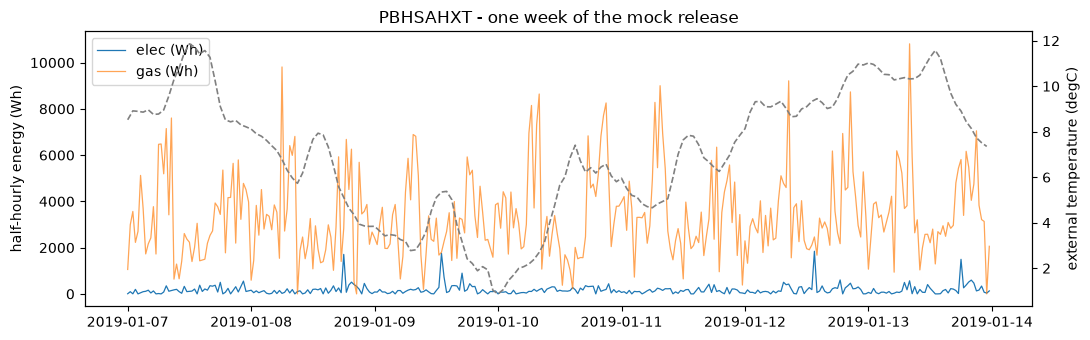

In [15]:
import matplotlib.pyplot as plt

week = slice('2019-01-07', '2019-01-13')
energy = home.data['energy_parameters'].loc[week]
climate = home.data['climate_parameters'].loc[week]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(energy.index, energy['elec'], lw=0.9, label='elec (Wh)')
ax.plot(energy.index, energy['gas'], lw=0.9, alpha=0.7, label='gas (Wh)')
ax.set_ylabel('half-hourly energy (Wh)')
ax.legend(loc='upper left')

temperature = ax.twinx()
temperature.plot(climate.index, climate['temp_ext'] - 273.15, color='grey', lw=1.2, ls='--')
temperature.set_ylabel('external temperature (degC)')

ax.set_title(f'{home.puprn} - one week of the mock release')
fig.tight_layout()
plt.show()

## 9. Cohort-wide questions

This is what the store is for, and what a per-household file layout cannot serve: one query
across every household, pruned on the timestamp zone maps. `scan()` keeps `PUPRN` as a column
rather than indexing, since the result spans households.

The five release files are also in the store, loaded verbatim — `source_table` reaches them, and
the survey keeps all of its columns. Those tables are the record; `puprn_info` is the curated
view over them.

In [16]:
import pandas as pd

january = store.scan(start=pd.Timestamp('2019-01-01'), end=pd.Timestamp('2019-02-01'),
                     columns=['PUPRN', 'ts', 'Elec_act_imp_hh_Wh', 'Gas_hh_Wh'])
print(january.shape)

january.groupby('PUPRN')[['Elec_act_imp_hh_Wh', 'Gas_hh_Wh']].agg(['mean', 'max', 'count'])

(2976, 4)


Elec_act_imp_hh_Wh                Gas_hh_Wh             
                       mean   max count         mean    max count
PUPRN                                                            
PBHSAHXT         180.818548  2278  1488  3289.504704  10812  1488
XAJI0Y6D         257.647849  2178  1488  3241.053763  10233  1488

In [17]:
# The release files themselves, straight out of the store.
store.source_table('rt_summary')[['PUPRN', 'deviceType', 'readType', 'percValid', 'percMissing']]

,PUPRN,deviceType,readType,percValid,percMissing
0,PBHSAHXT,ESME,AI,99.93,0.0
1,PBHSAHXT,ESME,DL,100.0,0.0
2,PBHSAHXT,ESME,RI,99.93,0.0
3,PBHSAHXT,GPF,AI,99.93,0.0
4,PBHSAHXT,GPF,DL,100.0,0.0
5,XAJI0Y6D,ESME,AI,99.93,0.0
6,XAJI0Y6D,ESME,DL,100.0,0.0
7,XAJI0Y6D,ESME,RI,99.93,0.0
8,XAJI0Y6D,GPF,AI,99.93,0.0
9,XAJI0Y6D,GPF,DL,100.0,0.0


## 10. The parquet cache, and swapping backends

`export_parquet_cache()` writes the second derived view: one fused energy+climate file per
household, `<root>/PUPRN=<puprn>/…parquet`, plus a `data_columns.json` manifest recording which
columns came from which series — that manifest is how the reader slices one series back out.

It costs storage (each grid cell's climate is duplicated across the households in it) and buys a
read that needs no join and no query engine. Which is faster depends on the workload; the
`scripts/benchmark_input_stores.py` in `serl-dataset` measures it properly, and only at real
scale — a dataset that fits in RAM measures the page cache, not the format.

Clearing `input_db` then switches the cohort onto the cache. **No code changes** — and the frames
that come back are identical.

In [18]:
cache_root = cohort.export_parquet_cache()
sorted(path.name for path in cache_root.iterdir())

['PUPRN=PBHSAHXT', 'PUPRN=XAJI0Y6D', 'data_columns.json']

In [19]:
store_frames = {frame: home._raw_frame(frame) for frame in ('energy', 'climate')}
cohort.store.close()          # release the file lock before re-resolving

cohort.dataset_config.update_with_settings(dict(input_dirs=dict(input_db='')),
                                           overwrite=True, save=True)

parquet_cohort = MockObservatory()
print('backend now:', parquet_cohort.input_backend)

parquet_home = parquet_cohort.get_dataset(house_number=1)
for frame, from_store in store_frames.items():
    from_cache = parquet_home._raw_frame(frame)
    pd.testing.assert_frame_equal(from_store.sort_index(axis=1), from_cache.sort_index(axis=1),
                                  check_dtype=False)
    print(f'{frame:<8} identical from both backends  {from_store.shape}')

backend now: ParquetBackend(C:\Users\corso\Documents\Projects\smeter-workspace\src\serl-mock\notebooks\example_cohort_workspace\energy_climate_data)


energy   identical from both backends  (17520, 14)
climate  identical from both backends  (744, 8)


In [20]:
# Put the store back, so re-running this notebook starts where it left off.
parquet_cohort.dataset_config.update_with_settings(
    dict(input_dirs=dict(input_db=str(STORE_PATH))), overwrite=True, save=True)

## 11. Variations

**A filtered cohort.** Declare the attribute in the spec, then filter on it. The filter runs
against the datasets table, so anything in `targets()` is available:

```python
class MockCoolingInfo(MockObservatoryInfo):
    pass                     # `cooling` is already declared above


class MockCooling(SERLBaseMixin, DatasetCohort):
    puprn_info_spec = MockCoolingInfo
    input_config_name = INPUT_CONFIG_NAME

    def __init__(self, **kwargs):
        super().__init__(settings=serl_base_settings, **kwargs)

    def _puprn_filters(self):
        return dict(cooling=1)
```

That is exactly how `SERLCooling` is built. A cohort defined this way gets its own config, its
own results database and its own store — which is the point when the cohort is a standing part of
the analysis, and overkill when it is one question.

**A sub-dataset** is the lighter alternative, and the one to reach for by default: it restricts
an existing cohort to a list of households without a new class, a new config or a new store.

In [21]:
low_imd = cohort.dataset_manager.jobs_to_df(cohort.dataset_manager.list_jobs())
low_imd = low_imd[low_imd['imd_quintile'].astype(float) <= 3].index.tolist()
print('households in IMD quintiles 1-3:', low_imd)

# Registers a dynamic subclass restricted to those households (save_dataset=False keeps it
# out of the shared datasets.json for this demo).
sub_cohort = cohort.create_sub_dataset('MockLowIMD', low_imd, save_dataset=False)
sub_cohort

households in IMD quintiles 1-3: ['PBHSAHXT']


__main__.MockLowIMD

## 12. Taking this to the real release

What changes, and what does not:

* **The input config paths** point at the release on the secure server instead of
  `serl-mock/data/mock/`. Nothing else in this notebook changes — that is the whole reason the
  mock release mirrors the Edition 08 file names and columns.
* **`Configuration_files/` stays environment-local.** It is gitignored deliberately: the package
  repos are byte-identical across environments and the configuration is not.
* **The store gets big.** Build it once, single-process, and let analysis workers open it
  read-only. Check the physical ordering earns its keep at real scale with
  `scripts/benchmark_input_stores.py`; the mock release (two households, one paired month of
  climate) cannot answer that.
* **A cohort that is here to stay belongs in `serl_dataset`**, as
  `src/serl_dataset/datasets/<name>/`, registered in `_DATASET_COHORTS` in
  `serl_dataset/__init__.py` so `get_dataset_cohort('<Name>')` finds it — and with a suite in
  `serl_dataset/testing/tests/`, which is still empty.

One caveat this notebook does not hide: the mock climate release covers **January 2019** while
the energy files cover the full year, so `climate_parameters` above is one month against twelve.
Regenerate the climate mock for more months if an analysis needs the overlap.

## Cleanup

Everything the notebook wrote is under `notebooks/example_cohort_workspace/` (gitignored). The
DuckDB file is held open by this kernel until the store is closed, so close it first.

In [22]:
import shutil

# store.close()
# shutil.rmtree(WORK_DIR)
print('to remove everything this notebook wrote, uncomment the two lines above')

to remove everything this notebook wrote, uncomment the two lines above
